## Drug Type and Presence encode information about drug-cognition interaction in Major Depression and Bipolar Disoder: A Multiple Correspondence Analysis approach

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import prince
import math

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Load data (farmaci a T0 e test a T1)

In [2]:
meds_range = slice("Benzodiazepines", "Aripiprazole(6)")
tests_range = slice("MMSE", "FAS")
t0 = pd.read_csv("T0.csv", sep=",", encoding="utf-8")
t1 = pd.read_csv("T1.csv", sep=",", encoding="utf-8")

# Keep only patients present in both timepoints
common_mask = t0["Name"].isin(t1["Name"])
t0 = t0[common_mask].sort_values("Name").reset_index(drop=True)
t1 = t1[t1["Name"].isin(t0["Name"])].sort_values("Name").reset_index(drop=True)

# Diagnosis 1: Depressed
mask_1 = t0["Diagnosis"] == 1
t0_1 = t0.loc[mask_1, meds_range]
t1_1_tests = t1.loc[mask_1, tests_range]
t0_1_tests = t0.loc[mask_1, tests_range]

# Diagnosis 2: Bipolar I
mask_2 = t0["Diagnosis"] == 2
t0_2 = t0.loc[mask_2, meds_range]
t1_2_tests = t1.loc[mask_2, tests_range]
t0_2_tests = t0.loc[mask_2, tests_range]

# Calculate Score Differences (T1 - T0)
columns_1 = t1_1_tests.columns
tdiff_1 = t1_1_tests.to_numpy() - t0_1_tests.to_numpy()

columns_2 = t1_2_tests.columns
tdiff_2 = t1_2_tests.to_numpy() - t0_2_tests.to_numpy()

print(f"Depressed (N={len(tdiff_1)}) | Bipolar (N={len(tdiff_2)})")

Depressed (N=28) | Bipolar (N=24)


In [3]:
# Initialize a data structure that allows us to collect performance data
# from each model. This is useful to compare the performance of the main model 
# (features encoding both type and presence) with the partial data models 
# (features encoding only type or only presence).

# Structure: {Target_Name: {Strategy_Name: [MSE, CI_Lower, CI_Upper]}}
target_comparison_md = {}
target_comparison_bp = {}

### Decoding drug-cognition interactions through MCA and predictive modelling.

Running a Ridge Regression model with Nested-Cross Validation (Robust) - MAJOR DEPRESSION

Processing Target 0: MMSE
MMSE Done | Mean Pearson R2: 0.2807 | Mean MAE: 3.6639
Processing Target 1: MoCA
MoCA Done | Mean Pearson R2: 0.2454 | Mean MAE: 2.5283
Processing Target 2: FAB
FAB Done | Mean Pearson R2: 0.2374 | Mean MAE: 1.9659
Processing Target 3: SPAN_A
SPAN_A Done | Mean Pearson R2: 0.1452 | Mean MAE: 0.9279
Processing Target 4: SPAN_I
SPAN_I Done | Mean Pearson R2: 0.2499 | Mean MAE: 1.0335
Processing Target 5: REY_I
REY_I Done | Mean Pearson R2: 0.0446 | Mean MAE: 7.1597
Processing Target 6: REY_D
REY_D Done | Mean Pearson R2: 0.1452 | Mean MAE: 2.3524
Processing Target 7: HDRS
HDRS Done | Mean Pearson R2: 0.2648 | Mean MAE: 6.7187
Processing Target 8: BDI
BDI Done | Mean Pearson R2: 0.1857 | Mean MAE: 11.3742
Processing Target 9: Vocab
Vocab Done | Mean Pearson R2: 0.2391 | Mean MAE: 1.5824
Processing Target 10: FAS
FAS Done | Mean Pearson R2: 0.1869 | Mean MAE: 6.6978


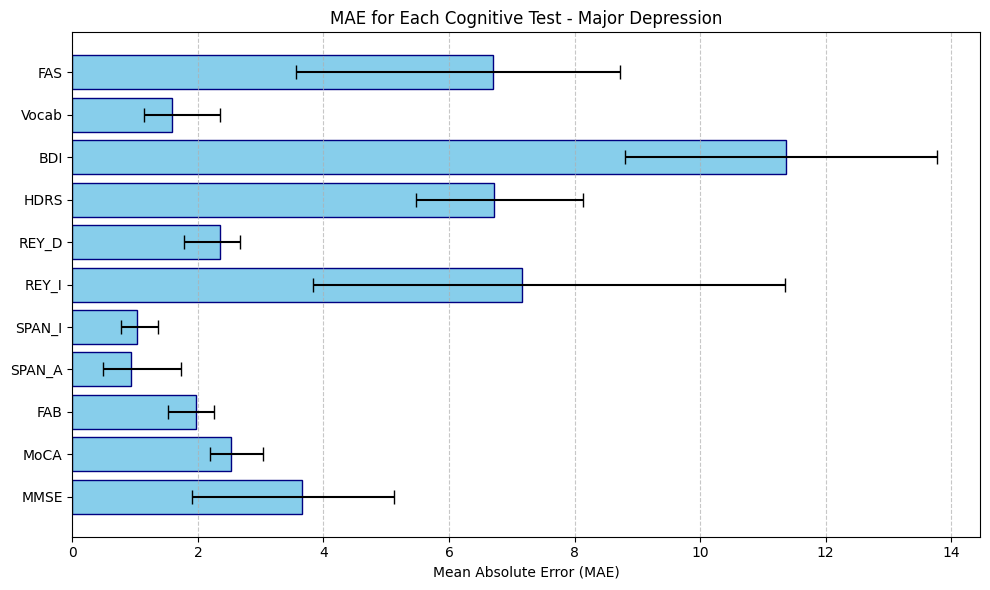

In [4]:
X_1 = t0_1
y_1 = pd.DataFrame(tdiff_1, columns=columns_1)

# Storage for models and interpretations
best_models_per_target = {}
coefficients_per_target = {}
mca_contributions_per_target = {}
mca_loadings_per_target = {}

# Storage for metrics and plotting
mae_scores = []
mse_scores = []
mae_ci_lower = []
mae_ci_upper = []
mse_ci_low_list = []
mse_ci_high_list = []
target_names = []
target_comparison_md = {} 

# Check that n_components is not more than n_features
max_comps = X_1.shape[1]
valid_comps = [c for c in [5, 15, 30] if c < max_comps]
if not valid_comps:
    valid_comps = [max(1, max_comps - 1)]

param_grid = {
    'mca__n_components': valid_comps,
    'model__alpha': [0.1, 1, 10]
}

outer_cv = KFold(n_splits=5, shuffle=True, random_state=44852523)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=73491241)

# Predictive model's loop
for idx, target in enumerate(y_1.columns):
    print(f"Processing Target {idx}: {target}")
    y_target = y_1[target]
    
    test_scores_mae = []
    test_scores_mse = []
    test_scores_r2 = []
    
    # Nested Cross-Validation (Performance Estimation)
    for train_idx, test_idx in outer_cv.split(X_1, y_target):
        X_train_cv, X_test_cv = X_1.iloc[train_idx], X_1.iloc[test_idx]
        y_train_cv, y_test_cv = y_target.iloc[train_idx], y_target.iloc[test_idx]
        
        pipeline = Pipeline([
            ('mca', prince.MCA(
                n_iter=5000, copy=True, check_input=True, 
                engine='sklearn', random_state=283434922)),
            ('model', Ridge())
        ])

        # We optimize for MAE, but we will track both MAE and MSE
        grid_search = GridSearchCV(
            pipeline, param_grid, cv=inner_cv, 
            scoring='neg_mean_absolute_error', n_jobs=8
        )
        grid_search.fit(X_train_cv, y_train_cv)
        
        y_pred = grid_search.best_estimator_.predict(X_test_cv)
        
        # Performance calculation
        mae = mean_absolute_error(y_test_cv, y_pred)
        mse = mean_squared_error(y_test_cv, y_pred)
        test_scores_mae.append(mae)
        test_scores_mse.append(mse)
        
        # Pearson R2 calculation
        if len(np.unique(y_test_cv)) > 1 and np.std(y_pred) > 0:
            r2 = np.corrcoef(y_test_cv, y_pred)[0][1]**2
        else:
            r2 = 0.0
        test_scores_r2.append(r2)

    # Final Model Fit
    final_pipeline = Pipeline([
        ('mca', prince.MCA(n_iter=5000, engine='sklearn', random_state=283434922)),
        ('model', Ridge())
    ])
    
    final_grid = GridSearchCV(final_pipeline, param_grid, cv=inner_cv, 
                              scoring='neg_mean_absolute_error', n_jobs=8)
    final_grid.fit(X_1, y_target)
    
    final_model = final_grid.best_estimator_
    best_models_per_target[target] = final_model
    
    # Extract Components & Coefficients
    ridge_step = final_model.named_steps['model']
    mca_step = final_model.named_steps['mca']
    
    coefficients_per_target[target] = ridge_step.coef_
    mca_contributions_per_target[target] = mca_step.column_contributions_
    mca_loadings_per_target[target] = mca_step.column_coordinates(X_1)

    # Statistics Reporting & Storage
    m_mae = np.mean(test_scores_mae)
    m_mse = np.mean(test_scores_mse)
    m_r2 = np.mean(test_scores_r2)
    
    low_mae, high_mae = np.percentile(test_scores_mae, [2.5, 97.5])
    low_mse, high_mse = np.percentile(test_scores_mse, [2.5, 97.5])
    
    # Update global lists
    target_names.append(target)
    mae_scores.append(m_mae)
    mse_scores.append(m_mse)
    mae_ci_lower.append(low_mae)
    mae_ci_upper.append(high_mae)
    mse_ci_low_list.append(low_mse)
    mse_ci_high_list.append(high_mse)

    print(f"{target} Done | Mean Pearson R2: {m_r2:.4f} | Mean MAE: {m_mae:.4f}")

    # Collection for Model Comparison
    strategy_name = "Full"
    if target not in target_comparison_md:
        target_comparison_md[target] = {}
    
    target_comparison_md[target][strategy_name] = {
        'mse': m_mse,
        'low': low_mse,
        'high': high_mse
    }

# Visualization (MAE)
plt.figure(figsize=(10, 6))
mae_errors = [
    np.array(mae_scores) - np.array(mae_ci_lower), 
    np.array(mae_ci_upper) - np.array(mae_scores)
]

plt.barh(target_names, mae_scores, xerr=mae_errors, capsize=5, color='skyblue', edgecolor='navy')
plt.xlabel('Mean Absolute Error (MAE)')
plt.title('MAE for Each Cognitive Test - Major Depression')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [5]:
print(best_models_per_target) # best overall model has 5 components and alpha = 1.0
print(final_model)

{'MMSE': Pipeline(steps=[('mca',
                 MCA(n_components=5, n_iter=5000, random_state=283434922)),
                ('model', Ridge(alpha=10))]), 'MoCA': Pipeline(steps=[('mca',
                 MCA(n_components=5, n_iter=5000, random_state=283434922)),
                ('model', Ridge(alpha=10))]), 'FAB': Pipeline(steps=[('mca',
                 MCA(n_components=5, n_iter=5000, random_state=283434922)),
                ('model', Ridge(alpha=10))]), 'SPAN_A': Pipeline(steps=[('mca',
                 MCA(n_components=5, n_iter=5000, random_state=283434922)),
                ('model', Ridge(alpha=10))]), 'SPAN_I': Pipeline(steps=[('mca',
                 MCA(n_components=5, n_iter=5000, random_state=283434922)),
                ('model', Ridge(alpha=10))]), 'REY_I': Pipeline(steps=[('mca',
                 MCA(n_components=5, n_iter=5000, random_state=283434922)),
                ('model', Ridge(alpha=10))]), 'REY_D': Pipeline(steps=[('mca',
                 MCA(n_components=30, 

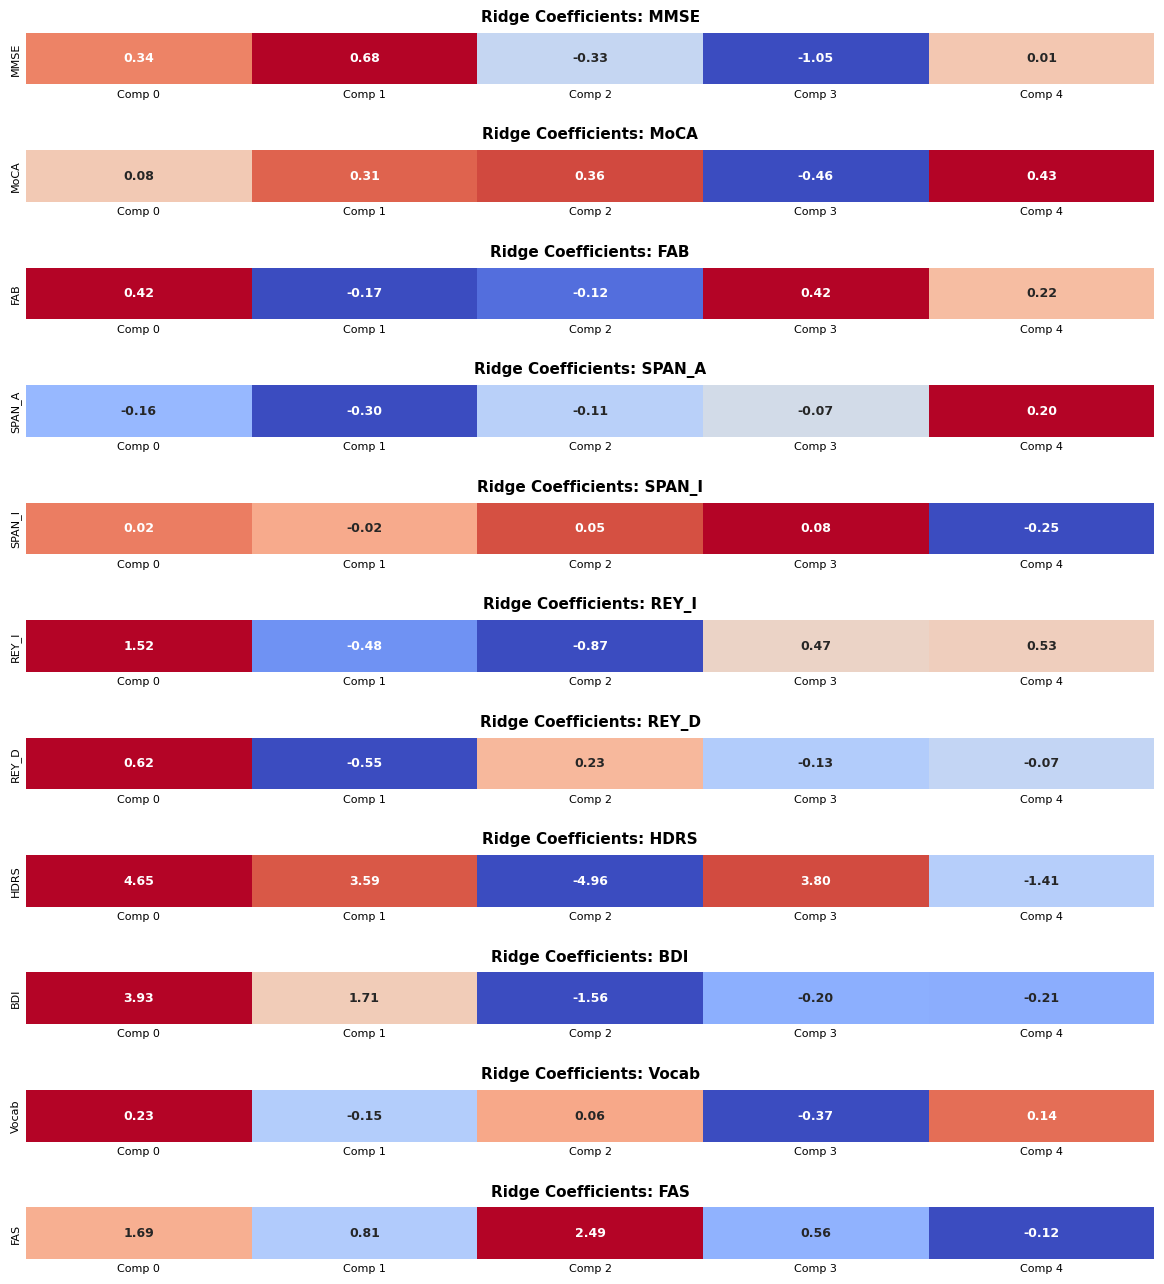

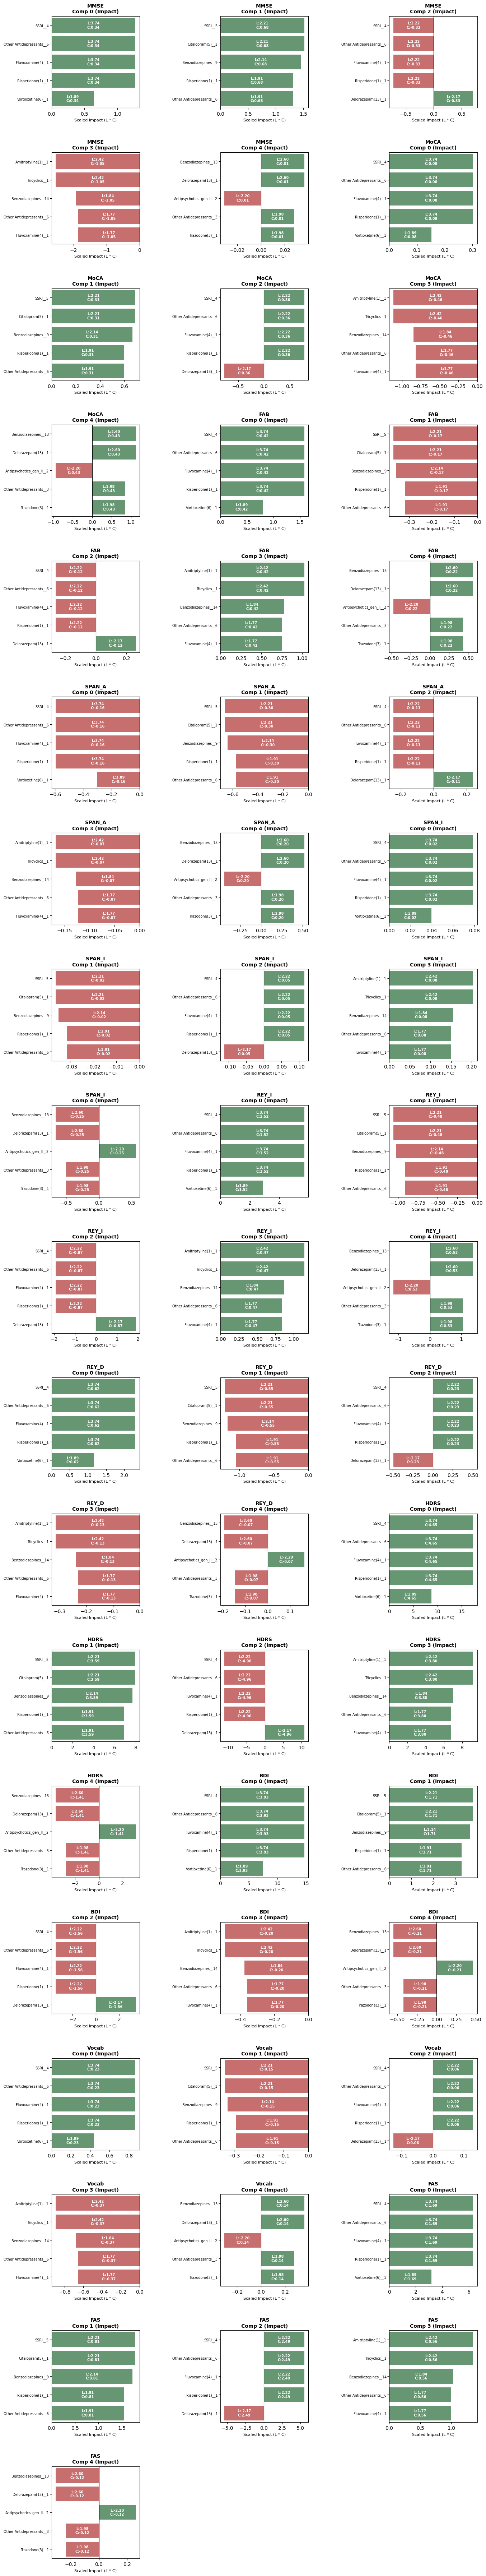

In [6]:
# Helper to truncate long feature names
def truncate_label(label, max_len=30):
    return str(label) if len(str(label)) <= max_len else str(label)[:max_len-3] + "..."

# Ridge Coefficients Heatmap
plt.figure(figsize=(12, 1.2 * len(target_names))) 
for i, target in enumerate(target_names):
    coefficients = coefficients_per_target[target]
    relative_coefficients = coefficients / np.sum(np.abs(coefficients))
    non_zero_indices = np.where(relative_coefficients != 0)[0][:5] 
    ax = plt.subplot(len(target_names), 1, i + 1)
    xticklabels = [f"Comp {j}" for j in non_zero_indices]
    sns.heatmap(coefficients[non_zero_indices].reshape(1, -1), annot=True,
                cmap="coolwarm", fmt=".2f", xticklabels=xticklabels,
                yticklabels=[target], cbar=False, annot_kws={"size": 9, "weight": "bold"})
    ax.set_title(f"Ridge Coefficients: {target}", fontsize=11, pad=8, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=8, length=0)
plt.tight_layout(pad=2.0)
plt.show()

# Scaled Loading Plots (Predictive Impact)
num_cols = 3 
num_top_contributors = 5
num_components_per_target = 5  

total_plots = len(target_names) * num_components_per_target
total_rows = math.ceil(total_plots / num_cols)

fig, axes = plt.subplots(total_rows, num_cols, figsize=(14.0, 3.8 * total_rows), sharey=False)
axes_flat = axes.flatten()
current_plot_idx = 0

for i, target in enumerate(target_names):
    loadings = mca_loadings_per_target[target]
    coeffs = coefficients_per_target[target]
    
    for j in range(num_components_per_target):
        ax = axes_flat[current_plot_idx]
        
        current_coeff = coeffs[j]
        scaled_loadings = loadings.iloc[:, j] * current_coeff
        
        # Get top 5 drugs by absolute impact
        top_indices = scaled_loadings.abs().sort_values(ascending=False).head(num_top_contributors).index
        top_values = scaled_loadings.loc[top_indices]
        raw_loadings = loadings.loc[top_indices, loadings.columns[j]]
        
        short_labels = [truncate_label(idx, max_len=30) for idx in top_indices]
        
        # Color mapping: red for negative impact, green for positive
        palette_map = {label: ('#d65f5f' if val < 0 else '#5f9e6e') 
                       for label, val in zip(short_labels, top_values)}
        
        sns.barplot(
            x=top_values, 
            y=short_labels, 
            ax=ax, 
            palette=palette_map,
            hue=short_labels, 
            legend=False,
            errorbar=None
        )
        
        # Center the text within each bar
        for idx, (val, l_val) in enumerate(zip(top_values, raw_loadings)):
            ax.text(
                x=val / 2, 
                y=idx, 
                s=f"L:{l_val:.2f}\nC:{current_coeff:.2f}", 
                va='center', 
                ha='center', 
                color='white', 
                fontweight='bold', 
                fontsize=7
            )
        
        ax.set_yticks(range(len(short_labels)))
        ax.set_yticklabels(short_labels, fontsize=7)
        ax.tick_params(axis='y', pad=2)
        ax.set_title(f'{target}\nComp {j} (Impact)', fontsize=10, fontweight='bold')
        ax.set_xlabel('Scaled Impact (L * C)', fontsize=8)
        ax.axvline(0, color='black', lw=0.8)
        current_plot_idx += 1

# Hide unused axes
for k in range(current_plot_idx, len(axes_flat)):
    axes_flat[k].axis('off')

plt.tight_layout(pad=2.5, w_pad=5.5, h_pad=3.5)
plt.show()

### Running a Ridge Regression model with Nested-Cross Validation (Robust) - BIPOLAR I

Processing Target 0: MMSE
MMSE Complete | Mean R2: 0.1979 | Mean MAE: 4.0081 | Mean MSE: 23.7719
Processing Target 1: MoCA
MoCA Complete | Mean R2: 0.5354 | Mean MAE: 2.3312 | Mean MSE: 8.6237
Processing Target 2: FAB
FAB Complete | Mean R2: 0.3294 | Mean MAE: 8.9913 | Mean MSE: 486.4407
Processing Target 3: SPAN_A
SPAN_A Complete | Mean R2: 0.3243 | Mean MAE: 0.7922 | Mean MSE: 1.0138
Processing Target 4: SPAN_I
SPAN_I Complete | Mean R2: 0.2787 | Mean MAE: 1.0470 | Mean MSE: 1.8106
Processing Target 5: REY_I
REY_I Complete | Mean R2: 0.4142 | Mean MAE: 8.0847 | Mean MSE: 101.5725
Processing Target 6: REY_D
REY_D Complete | Mean R2: 0.2117 | Mean MAE: 2.4599 | Mean MSE: 13.1254
Processing Target 7: HDRS
HDRS Complete | Mean R2: 0.1733 | Mean MAE: 8.5715 | Mean MSE: 121.6881
Processing Target 8: BDI
BDI Complete | Mean R2: 0.5616 | Mean MAE: 13.9816 | Mean MSE: 318.9977
Processing Target 9: Vocab
Vocab Complete | Mean R2: 0.1175 | Mean MAE: 1.8552 | Mean MSE: 5.0832
Processing Target 1

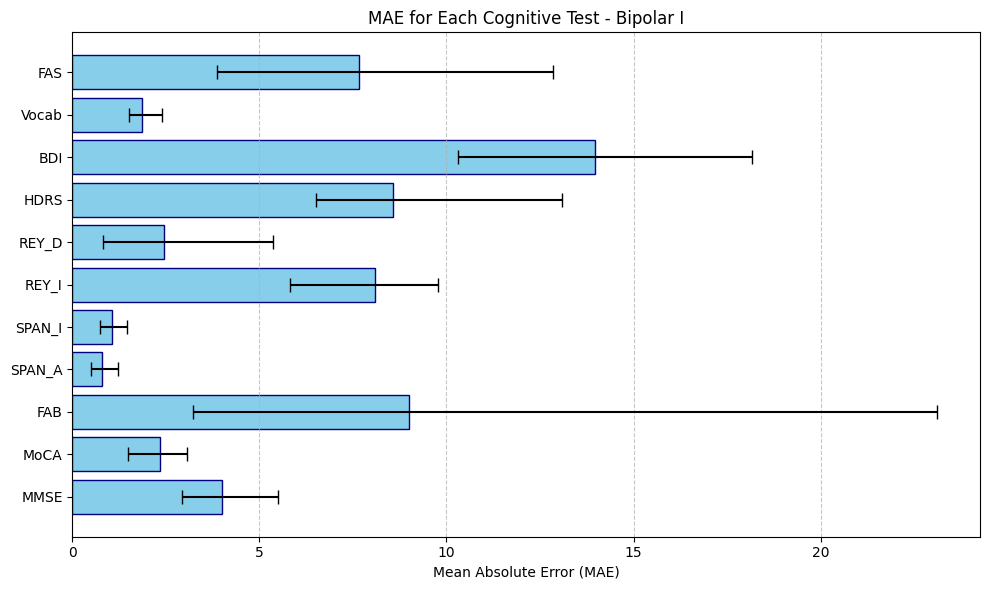

In [7]:
X_2 = t0_2
y_2 = pd.DataFrame(tdiff_2, columns=columns_2)

# Fix one NaN in Span_A (global fix before split)
y_2.fillna(0, inplace=True)

best_models_per_target = {}
coefficients_per_target = {}
mca_contributions_per_target = {}
mca_loadings_per_target = {}

# Statistics for plotting (MAE) and Comparison (MSE)
mae_scores = []
mae_ci_lower = []
mae_ci_upper = []

mse_scores = []
mse_ci_low_list = []
mse_ci_high_list = []

target_names = []
target_comparison_bp = {}

# make sure n_components is not higher than n_features
max_comps = X_2.shape[1]
potential_comps = [5, 15, 30]
valid_comps = [c for c in potential_comps if c < max_comps]
if not valid_comps:
    valid_comps = [max(1, max_comps - 1)]

param_grid = {
    'mca__n_components': valid_comps,
    'model__alpha': [0.1, 1, 10]
}

outer_cv = KFold(n_splits=5, shuffle=True, random_state=44852523)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=73491241)

# Predictive model's loop
for idx, target in enumerate(y_2.columns):
    print(f"Processing Target {idx}: {target}")
    y_target = y_2[target]
    
    test_scores_mae = []
    test_scores_mse = []
    test_scores_r2 = []
    
    # Define the base pipeline
    pipeline = Pipeline([
        ('mca', prince.MCA(
            n_iter=5000, copy=True, check_input=True, 
            engine='sklearn', random_state=283434922)),
        ('model', Ridge())
    ])

    # Nested Cross-Validation (Evaluation)
    for train_idx, test_idx in outer_cv.split(X_2, y_target):
        X_train_cv, X_test_cv = X_2.iloc[train_idx], X_2.iloc[test_idx]
        y_train_cv, y_test_cv = y_target.iloc[train_idx], y_target.iloc[test_idx]
        
        # GridSearch within the fold
        grid_search = GridSearchCV(
            pipeline, param_grid, cv=inner_cv, 
            scoring='neg_mean_absolute_error', n_jobs=8
        )
        grid_search.fit(X_train_cv, y_train_cv)
        
        y_pred = grid_search.best_estimator_.predict(X_test_cv)
        test_scores_mae.append(mean_absolute_error(y_test_cv, y_pred))
        test_scores_mse.append(mean_squared_error(y_test_cv, y_pred)) # Added MSE
        
        # Pearson R2
        if len(np.unique(y_test_cv)) > 1 and np.std(y_pred) > 0:
            r2 = np.corrcoef(y_test_cv, y_pred)[0][1]**2
        else:
            r2 = 0.0
        test_scores_r2.append(r2)

    # Final Model Fit
    final_grid = GridSearchCV(pipeline, param_grid, cv=inner_cv, 
                              scoring='neg_mean_absolute_error', n_jobs=8)
    final_grid.fit(X_2, y_target)
    
    final_model = final_grid.best_estimator_
    best_models_per_target[target] = final_model
    
    # Extract Interpretation Data from Final Model
    ridge_step = final_model.named_steps['model']
    mca_step = final_model.named_steps['mca']
    
    coefficients_per_target[target] = ridge_step.coef_
    mca_contributions_per_target[target] = mca_step.column_contributions_
    mca_loadings_per_target[target] = mca_step.column_coordinates(X_2)

    # Stats Reporting and Storage
    m_mae = np.mean(test_scores_mae)
    m_mse = np.mean(test_scores_mse)
    m_r2 = np.mean(test_scores_r2)
    
    low_mae, high_mae = np.percentile(test_scores_mae, [2.5, 97.5])
    low_mse, high_mse = np.percentile(test_scores_mse, [2.5, 97.5])
    
    # Append to global plotting lists
    target_names.append(target)
    mae_scores.append(m_mae)
    mae_ci_lower.append(low_mae)
    mae_ci_upper.append(high_mae)
    
    # Append to MSE lists
    mse_scores.append(m_mse)
    mse_ci_low_list.append(low_mse)
    mse_ci_high_list.append(high_mse)

    print(f"{target} Complete | Mean R2: {m_r2:.4f} | Mean MAE: {m_mae:.4f} | Mean MSE: {m_mse:.4f}")

    # Collection for Model Comparison
    strategy_name = "Full"
    if target not in target_comparison_bp:
        target_comparison_bp[target] = {}
    
    target_comparison_bp[target][strategy_name] = {
        'mse': m_mse,
        'low': low_mse,
        'high': high_mse
    }

# Visualization (MAE)
plt.figure(figsize=(10, 6))
error_bars = [
    np.array(mae_scores) - np.array(mae_ci_lower), 
    np.array(mae_ci_upper) - np.array(mae_scores)
]

plt.barh(target_names, mae_scores, xerr=error_bars, capsize=5, color='skyblue', edgecolor='navy')
plt.xlabel('Mean Absolute Error (MAE)')
plt.title('MAE for Each Cognitive Test - Bipolar I')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [8]:
print(best_models_per_target) # best overall model has 5 components and alpha = 10.0
print(final_model)

{'MMSE': Pipeline(steps=[('mca',
                 MCA(n_components=5, n_iter=5000, random_state=283434922)),
                ('model', Ridge(alpha=0.1))]), 'MoCA': Pipeline(steps=[('mca',
                 MCA(n_components=30, n_iter=5000, random_state=283434922)),
                ('model', Ridge(alpha=10))]), 'FAB': Pipeline(steps=[('mca',
                 MCA(n_components=5, n_iter=5000, random_state=283434922)),
                ('model', Ridge(alpha=10))]), 'SPAN_A': Pipeline(steps=[('mca',
                 MCA(n_components=5, n_iter=5000, random_state=283434922)),
                ('model', Ridge(alpha=10))]), 'SPAN_I': Pipeline(steps=[('mca',
                 MCA(n_components=5, n_iter=5000, random_state=283434922)),
                ('model', Ridge(alpha=1))]), 'REY_I': Pipeline(steps=[('mca',
                 MCA(n_components=5, n_iter=5000, random_state=283434922)),
                ('model', Ridge(alpha=0.1))]), 'REY_D': Pipeline(steps=[('mca',
                 MCA(n_components=5,

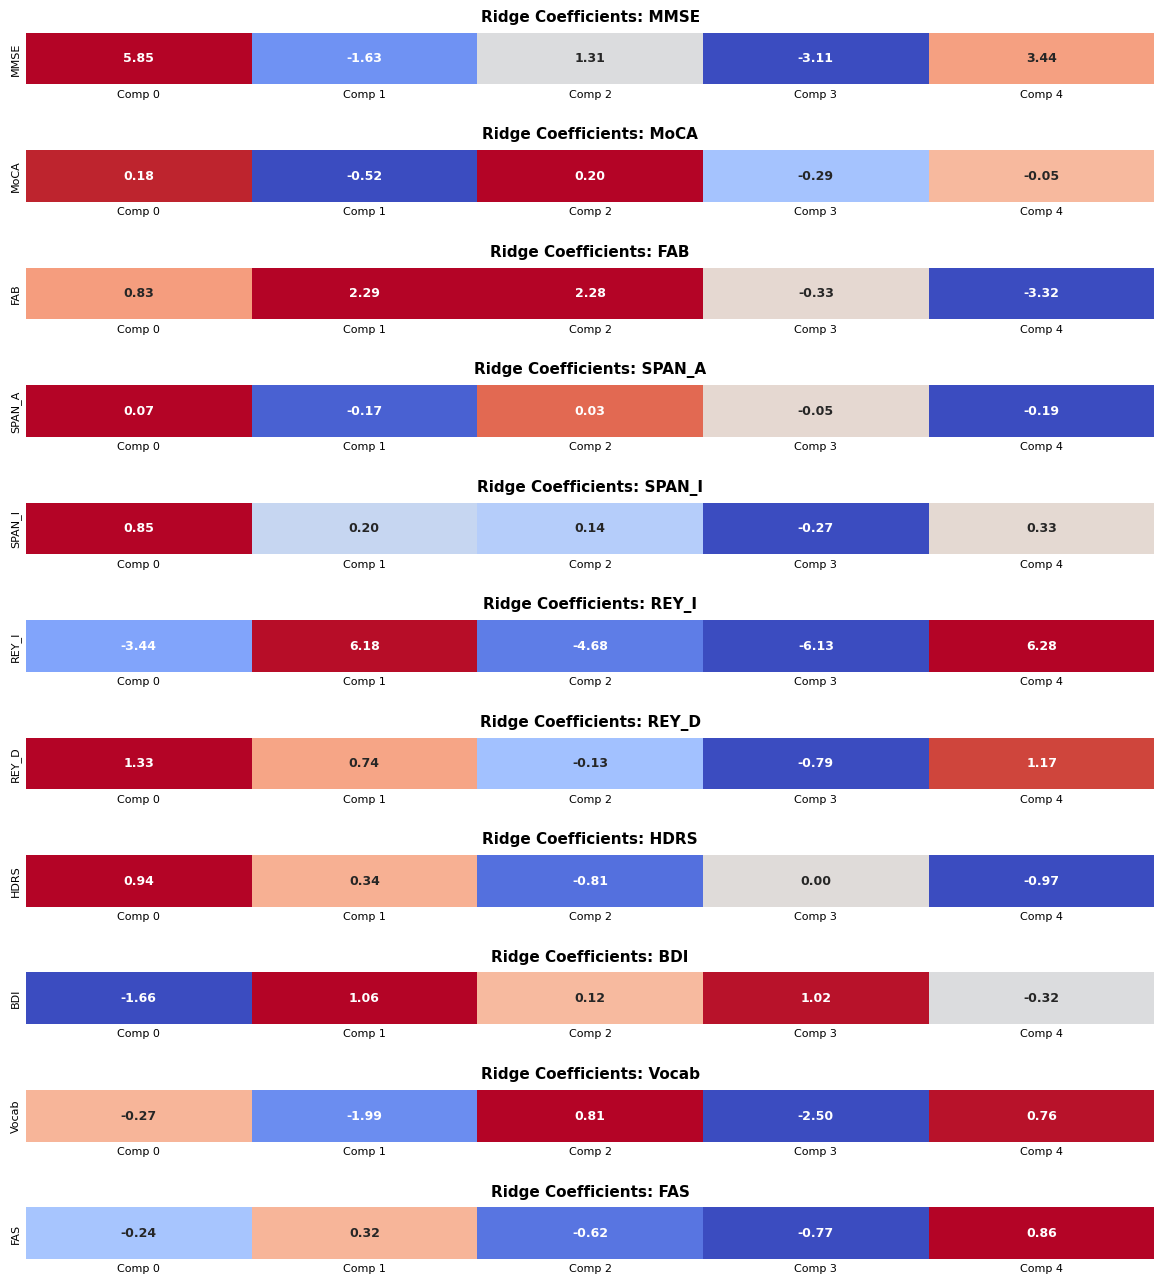

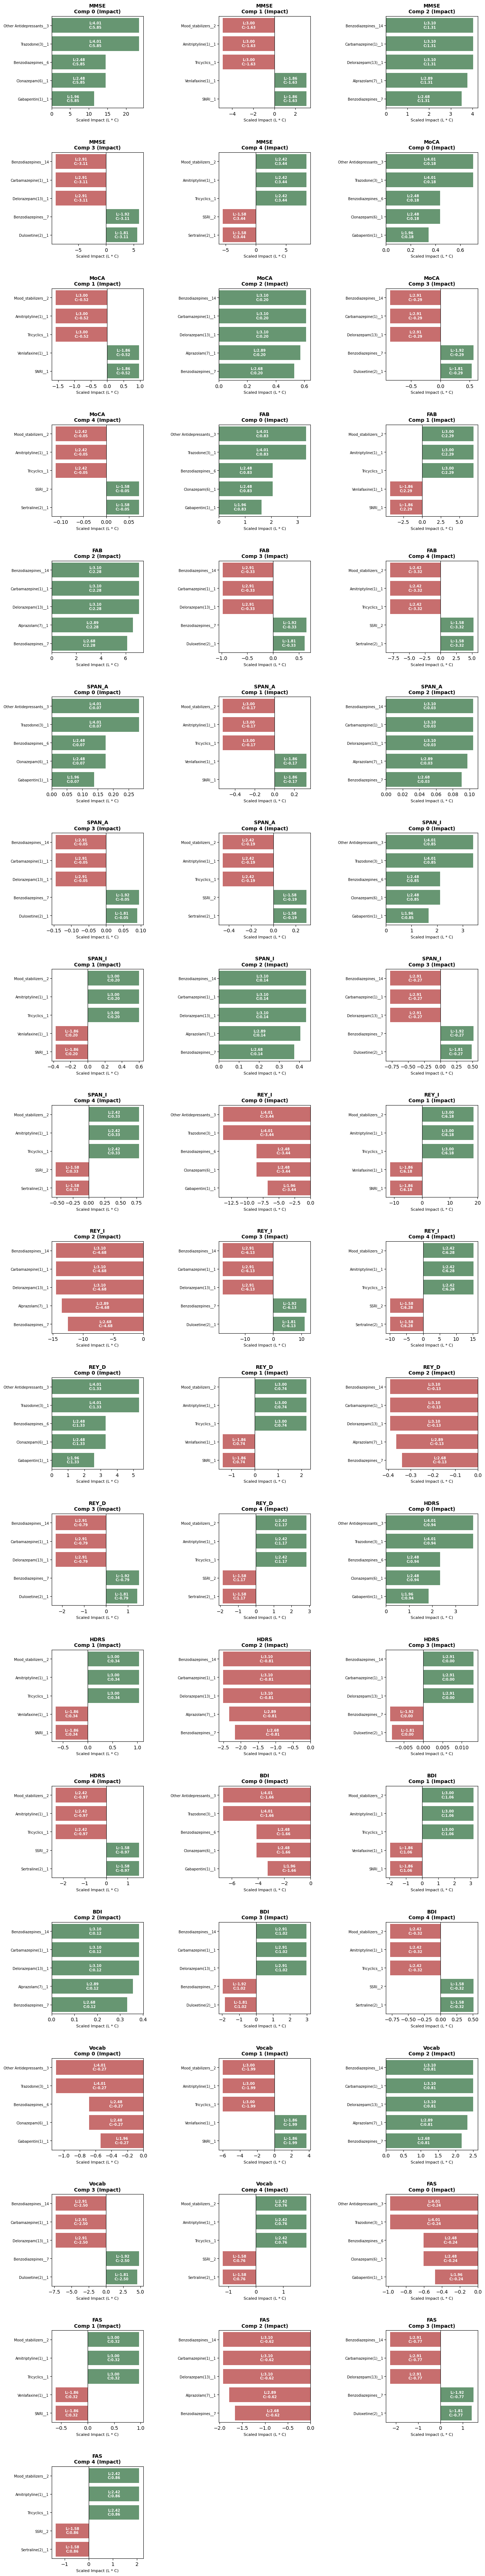

In [9]:
# Helper to truncate long feature names
def truncate_label(label, max_len=30):
    return str(label) if len(str(label)) <= max_len else str(label)[:max_len-3] + "..."

# Ridge Coefficients Heatmap
plt.figure(figsize=(12, 1.2 * len(target_names))) 
for i, target in enumerate(target_names):
    coefficients = coefficients_per_target[target]
    relative_coefficients = coefficients / np.sum(np.abs(coefficients))
    non_zero_indices = np.where(relative_coefficients != 0)[0][:5] 
    ax = plt.subplot(len(target_names), 1, i + 1)
    xticklabels = [f"Comp {j}" for j in non_zero_indices]
    sns.heatmap(coefficients[non_zero_indices].reshape(1, -1), annot=True,
                cmap="coolwarm", fmt=".2f", xticklabels=xticklabels,
                yticklabels=[target], cbar=False, annot_kws={"size": 9, "weight": "bold"})
    ax.set_title(f"Ridge Coefficients: {target}", fontsize=11, pad=8, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=8, length=0)
plt.tight_layout(pad=2.0)
plt.show()

# Scaled Loading Plots (Predictive Impact)
num_cols = 3 
num_top_contributors = 5
num_components_per_target = 5  

total_plots = len(target_names) * num_components_per_target
total_rows = math.ceil(total_plots / num_cols)

fig, axes = plt.subplots(total_rows, num_cols, figsize=(14.0, 3.8 * total_rows), sharey=False)
axes_flat = axes.flatten()
current_plot_idx = 0

for i, target in enumerate(target_names):
    loadings = mca_loadings_per_target[target]
    coeffs = coefficients_per_target[target]
    
    for j in range(num_components_per_target):
        ax = axes_flat[current_plot_idx]
        
        current_coeff = coeffs[j]
        scaled_loadings = loadings.iloc[:, j] * current_coeff
        
        # Get top 5 drugs by absolute impact
        top_indices = scaled_loadings.abs().sort_values(ascending=False).head(num_top_contributors).index
        top_values = scaled_loadings.loc[top_indices]
        raw_loadings = loadings.loc[top_indices, loadings.columns[j]]
        
        short_labels = [truncate_label(idx, max_len=30) for idx in top_indices]
        
        # Color mapping: red for negative impact, green for positive
        palette_map = {label: ('#d65f5f' if val < 0 else '#5f9e6e') 
                       for label, val in zip(short_labels, top_values)}
        
        sns.barplot(
            x=top_values, 
            y=short_labels, 
            ax=ax, 
            palette=palette_map,
            hue=short_labels, 
            legend=False,
            errorbar=None
        )
        
        # Center the text within each bar
        for idx, (val, l_val) in enumerate(zip(top_values, raw_loadings)):
            ax.text(
                x=val / 2, 
                y=idx, 
                s=f"L:{l_val:.2f}\nC:{current_coeff:.2f}", 
                va='center', 
                ha='center', 
                color='white', 
                fontweight='bold', 
                fontsize=7
            )
        
        ax.set_yticks(range(len(short_labels)))
        ax.set_yticklabels(short_labels, fontsize=7)
        ax.tick_params(axis='y', pad=2)
        ax.set_title(f'{target}\nComp {j} (Impact)', fontsize=10, fontweight='bold')
        ax.set_xlabel('Scaled Impact (L * C)', fontsize=8)
        ax.axvline(0, color='black', lw=0.8)
        current_plot_idx += 1

# Hide unused axes
for k in range(current_plot_idx, len(axes_flat)):
    axes_flat[k].axis('off')

plt.tight_layout(pad=2.5, w_pad=5.5, h_pad=3.5)
plt.show()

### Re-evaluate the models only with type-related features (Major Depression)

Original feature count: 40
Filtered feature count (values > 1): 5
Processing Target 0: MMSE
MMSE Done | Mean R2: 0.2784 | Mean MAE: 3.4758
Processing Target 1: MoCA
MoCA Done | Mean R2: 0.1810 | Mean MAE: 2.3849
Processing Target 2: FAB
FAB Done | Mean R2: 0.1971 | Mean MAE: 1.9911
Processing Target 3: SPAN_A
SPAN_A Done | Mean R2: 0.1848 | Mean MAE: 0.9692
Processing Target 4: SPAN_I
SPAN_I Done | Mean R2: 0.2262 | Mean MAE: 0.9705
Processing Target 5: REY_I
REY_I Done | Mean R2: 0.0213 | Mean MAE: 7.0570
Processing Target 6: REY_D
REY_D Done | Mean R2: 0.2100 | Mean MAE: 2.2887
Processing Target 7: HDRS
HDRS Done | Mean R2: 0.1529 | Mean MAE: 6.6509
Processing Target 8: BDI
BDI Done | Mean R2: 0.0971 | Mean MAE: 11.8711
Processing Target 9: Vocab
Vocab Done | Mean R2: 0.3500 | Mean MAE: 1.6485
Processing Target 10: FAS
FAS Done | Mean R2: 0.1754 | Mean MAE: 6.3867


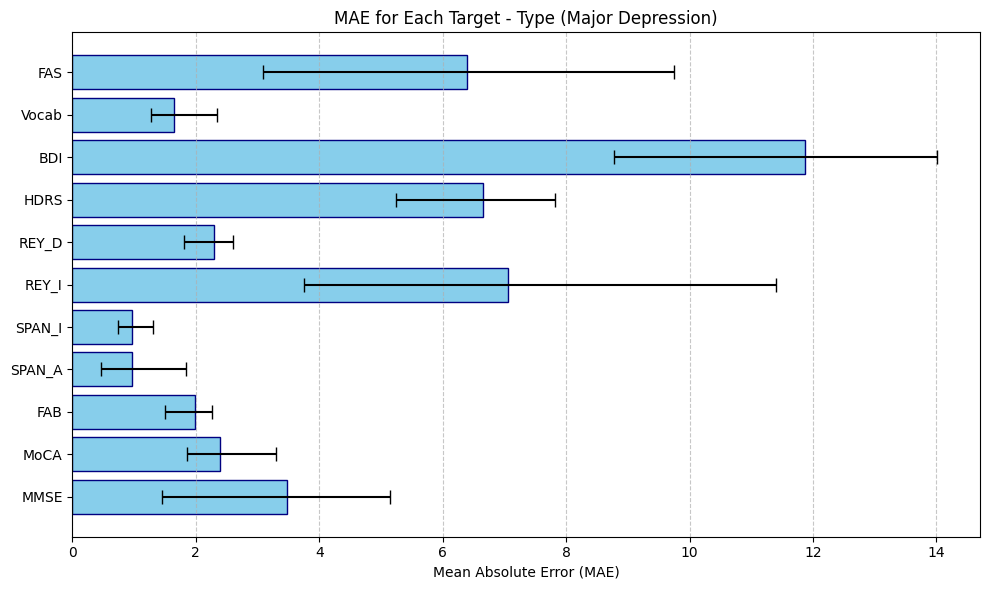

In [10]:
# Uncommented code, see previous models!!!

X_initial = t0_1
y_1 = pd.DataFrame(tdiff_1, columns=columns_1)

features_to_keep = X_initial.columns[(X_initial > 1).any()]
X_1 = X_initial[features_to_keep].copy()

print(f"Original feature count: {X_initial.shape[1]}")
print(f"Filtered feature count (values > 1): {X_1.shape[1]}")

best_models_per_target = {}
coefficients_per_target = {}
mca_contributions_per_target = {}
mca_loadings_per_target = {}

mae_scores = []
mae_ci_lower = []
mae_ci_upper = []
mse_scores = []
mse_ci_low_list = []
mse_ci_high_list = []
target_names = []

max_possible_comps = X_1.shape[1]
potential_comps = [5, 15, 30]
valid_comps = [c for c in potential_comps if c < max_possible_comps]
if not valid_comps:
    valid_comps = [max(1, max_possible_comps - 1)]

param_grid = {
    'mca__n_components': valid_comps,
    'model__alpha': [0.1, 1, 10]
}

outer_cv = KFold(n_splits=5, shuffle=True, random_state=44852523)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=73491241)

for idx, target in enumerate(y_1.columns):
    print(f"Processing Target {idx}: {target}")
    y_target = y_1[target]
    
    test_scores_mae = []
    test_scores_mse = []
    test_scores_r2 = []
    
    pipeline = Pipeline([
        ('mca', prince.MCA(
            n_iter=5000, copy=True, check_input=True, 
            engine='sklearn', random_state=283434922)),
        ('model', Ridge())
    ])

    for train_idx, test_idx in outer_cv.split(X_1, y_target):
        X_train_cv, X_test_cv = X_1.iloc[train_idx], X_1.iloc[test_idx]
        y_train_cv, y_test_cv = y_target.iloc[train_idx], y_target.iloc[test_idx]
        
        grid_search = GridSearchCV(
            pipeline, param_grid, cv=inner_cv, 
            scoring='neg_mean_absolute_error', n_jobs=8
        )
        grid_search.fit(X_train_cv, y_train_cv)
        
        y_pred = grid_search.best_estimator_.predict(X_test_cv)
        
        test_scores_mae.append(mean_absolute_error(y_test_cv, y_pred))
        test_scores_mse.append(mean_squared_error(y_test_cv, y_pred)) # Added
        
        if len(np.unique(y_test_cv)) > 1 and np.std(y_pred) > 0:
            r2 = np.corrcoef(y_test_cv, y_pred)[0][1]**2
        else:
            r2 = 0.0
        test_scores_r2.append(r2)

    final_grid = GridSearchCV(pipeline, param_grid, cv=inner_cv, 
                              scoring='neg_mean_absolute_error', n_jobs=8)
    final_grid.fit(X_1, y_target)
    
    final_model = final_grid.best_estimator_
    best_models_per_target[target] = final_model
    
    ridge_step = final_model.named_steps['model']
    mca_step = final_model.named_steps['mca']
    
    coefficients_per_target[target] = ridge_step.coef_
    mca_contributions_per_target[target] = mca_step.column_contributions_
    mca_loadings_per_target[target] = mca_step.column_coordinates(X_1)

    m_mae = np.mean(test_scores_mae)
    m_mse = np.mean(test_scores_mse)
    m_r2 = np.mean(test_scores_r2)
    
    low_mae, high_mae = np.percentile(test_scores_mae, [2.5, 97.5])
    low_mse, high_mse = np.percentile(test_scores_mse, [2.5, 97.5])
    
    target_names.append(target)
    mae_scores.append(m_mae)
    mae_ci_lower.append(low_mae)
    mae_ci_upper.append(high_mae)
    
    mse_scores.append(m_mse)
    mse_ci_low_list.append(low_mse)
    mse_ci_high_list.append(high_mse)

    print(f"{target} Done | Mean R2: {m_r2:.4f} | Mean MAE: {m_mae:.4f}")

    strategy_name = "Type" 
    if target not in target_comparison_md:
        target_comparison_md[target] = {}
        
    target_comparison_md[target][strategy_name] = {
        'mse': m_mse,
        'low': low_mse,
        'high': high_mse
    }

plt.figure(figsize=(10, 6))
error_bars = [
    np.array(mae_scores) - np.array(mae_ci_lower), 
    np.array(mae_ci_upper) - np.array(mae_scores)
]
plt.barh(target_names, mae_scores, xerr=error_bars, capsize=5, color='skyblue', edgecolor='navy')
plt.xlabel('Mean Absolute Error (MAE)')
plt.title('MAE for Each Target - Type (Major Depression)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Original feature count: 40
Features kept (max <= 1 and non-constant): 29
Processing Target 0: MMSE
Result for MMSE: Pearson R2: 0.3639, MAE: 3.7020, MSE: 25.2928
Processing Target 1: MoCA
Result for MoCA: Pearson R2: 0.2744, MAE: 2.5027, MSE: 8.9657
Processing Target 2: FAB
Result for FAB: Pearson R2: 0.1813, MAE: 2.0188, MSE: 6.3229
Processing Target 3: SPAN_A
Result for SPAN_A: Pearson R2: 0.2980, MAE: 0.9353, MSE: 2.0312
Processing Target 4: SPAN_I
Result for SPAN_I: Pearson R2: 0.2546, MAE: 1.0660, MSE: 1.7824
Processing Target 5: REY_I
Result for REY_I: Pearson R2: 0.3571, MAE: 6.9647, MSE: 75.6530
Processing Target 6: REY_D
Result for REY_D: Pearson R2: 0.1220, MAE: 2.3569, MSE: 9.5136
Processing Target 7: HDRS
Result for HDRS: Pearson R2: 0.3959, MAE: 6.8559, MSE: 66.4254
Processing Target 8: BDI
Result for BDI: Pearson R2: 0.2131, MAE: 10.6083, MSE: 162.1339
Processing Target 9: Vocab
Result for Vocab: Pearson R2: 0.2879, MAE: 1.5566, MSE: 4.5509
Processing Target 10: FAS
Resul

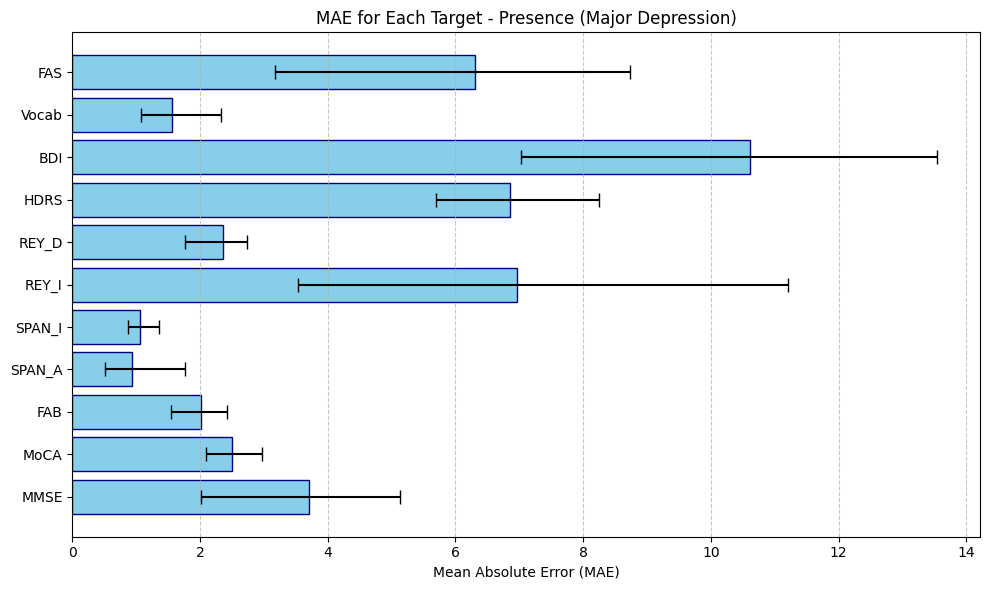

In [11]:
# Uncommented code, see previous models!!!

X_initial = t0_1
y_1 = pd.DataFrame(tdiff_1, columns=columns_1)

features_to_keep = X_initial.columns[(X_initial.max() <= 1) & (X_initial.nunique() > 1)]
X_1 = X_initial[features_to_keep].copy()

print(f"Original feature count: {X_initial.shape[1]}")
print(f"Features kept (max <= 1 and non-constant): {X_1.shape[1]}")

best_models_per_target = {}
coefficients_per_target = {}
mca_contributions_per_target = {}
mca_loadings_per_target = {}

mae_scores = []
mae_ci_lower = []
mae_ci_upper = []

mse_scores = []
mse_ci_low_list = []
mse_ci_high_list = []

target_names = []

n_f = X_1.shape[1]
potential_comps = [5, 15, 30]
valid_comps = [c for c in potential_comps if c < n_f]
if not valid_comps:
    valid_comps = [max(1, n_f - 1)]

param_grid = {
    'mca__n_components': valid_comps,
    'model__alpha': [0.1, 1, 10]
}

outer_cv = KFold(n_splits=5, shuffle=True, random_state=44852523)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=73491241)

for idx, target in enumerate(y_1.columns):
    print(f"Processing Target {idx}: {target}")
    y_target = y_1[target]
    
    test_scores_mae = []
    test_scores_mse = []
    test_scores_r2 = []
    
    pipeline = Pipeline([
        ('mca', prince.MCA(
            n_iter=5000, copy=True, check_input=True, 
            engine='sklearn', random_state=283434922)),
        ('model', Ridge())
    ])

    for train_idx, test_idx in outer_cv.split(X_1, y_target):
        X_train_cv, X_test_cv = X_1.iloc[train_idx], X_1.iloc[test_idx]
        y_train_cv, y_test_cv = y_target.iloc[train_idx], y_target.iloc[test_idx]
        
        grid_search_cv = GridSearchCV(
            pipeline, param_grid, cv=inner_cv, 
            scoring='neg_mean_absolute_error', n_jobs=8
        )
        grid_search_cv.fit(X_train_cv, y_train_cv)
        
        y_pred = grid_search_cv.best_estimator_.predict(X_test_cv)
        
        test_scores_mae.append(mean_absolute_error(y_test_cv, y_pred))
        test_scores_mse.append(mean_squared_error(y_test_cv, y_pred)) # Added MSE
        
        if len(np.unique(y_test_cv)) > 1 and np.std(y_pred) > 0:
            r2 = np.corrcoef(y_test_cv, y_pred)[0][1]**2
        else:
            r2 = 0.0
        test_scores_r2.append(r2)

    final_grid = GridSearchCV(pipeline, param_grid, cv=inner_cv, 
                              scoring='neg_mean_absolute_error', n_jobs=8)
    final_grid.fit(X_1, y_target)
    
    final_model = final_grid.best_estimator_
    best_models_per_target[target] = final_model
    
    ridge_step = final_model.named_steps['model']
    mca_step = final_model.named_steps['mca']
    
    coefficients_per_target[target] = ridge_step.coef_
    mca_contributions_per_target[target] = mca_step.column_contributions_
    mca_loadings_per_target[target] = mca_step.column_coordinates(X_1)

    m_mae = np.mean(test_scores_mae)
    m_mse = np.mean(test_scores_mse)
    m_r2 = np.mean(test_scores_r2)
    
    low_mae, high_mae = np.percentile(test_scores_mae, [2.5, 97.5])
    low_mse, high_mse = np.percentile(test_scores_mse, [2.5, 97.5])
    
    target_names.append(target)
    mae_scores.append(m_mae)
    mae_ci_lower.append(low_mae)
    mae_ci_upper.append(high_mae)
    
    mse_scores.append(m_mse)
    mse_ci_low_list.append(low_mse)
    mse_ci_high_list.append(high_mse)

    print(f"Result for {target}: Pearson R2: {m_r2:.4f}, MAE: {m_mae:.4f}, MSE: {m_mse:.4f}")

    strategy_name = "Presence" 
    if target not in target_comparison_md:
        target_comparison_md[target] = {}
        
    target_comparison_md[target][strategy_name] = {
        'mse': m_mse,
        'low': low_mse,
        'high': high_mse
    }

plt.figure(figsize=(10, 6))
error_bars = [
    np.array(mae_scores) - np.array(mae_ci_lower), 
    np.array(mae_ci_upper) - np.array(mae_scores)
]
plt.barh(target_names, mae_scores, xerr=error_bars, capsize=5, color='skyblue', edgecolor='navy')
plt.xlabel('Mean Absolute Error (MAE)')
plt.title('MAE for Each Target - Presence (Major Depression)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Re-evaluate the models only with type-related features (Bipolar I)

Original feature count: 40
Filtered feature count (values > 1): 5
Processing Target 0: MMSE
MMSE Done | Mean R2: 0.3693 | Mean MAE: 2.9993 | Mean MSE: 15.0296
Processing Target 1: MoCA
MoCA Done | Mean R2: 0.2356 | Mean MAE: 2.2566 | Mean MSE: 8.3152
Processing Target 2: FAB
FAB Done | Mean R2: 0.4511 | Mean MAE: 9.1229 | Mean MSE: 489.7231
Processing Target 3: SPAN_A
SPAN_A Done | Mean R2: 0.1131 | Mean MAE: 0.7170 | Mean MSE: 0.9180
Processing Target 4: SPAN_I
SPAN_I Done | Mean R2: 0.3672 | Mean MAE: 1.0224 | Mean MSE: 1.7588
Processing Target 5: REY_I
REY_I Done | Mean R2: 0.3730 | Mean MAE: 8.7859 | Mean MSE: 122.5031
Processing Target 6: REY_D
REY_D Done | Mean R2: 0.2322 | Mean MAE: 2.4004 | Mean MSE: 13.0534
Processing Target 7: HDRS
HDRS Done | Mean R2: 0.2714 | Mean MAE: 9.1396 | Mean MSE: 124.0388
Processing Target 8: BDI
BDI Done | Mean R2: 0.1774 | Mean MAE: 14.3580 | Mean MSE: 324.5235
Processing Target 9: Vocab
Vocab Done | Mean R2: 0.3779 | Mean MAE: 1.9214 | Mean MSE: 

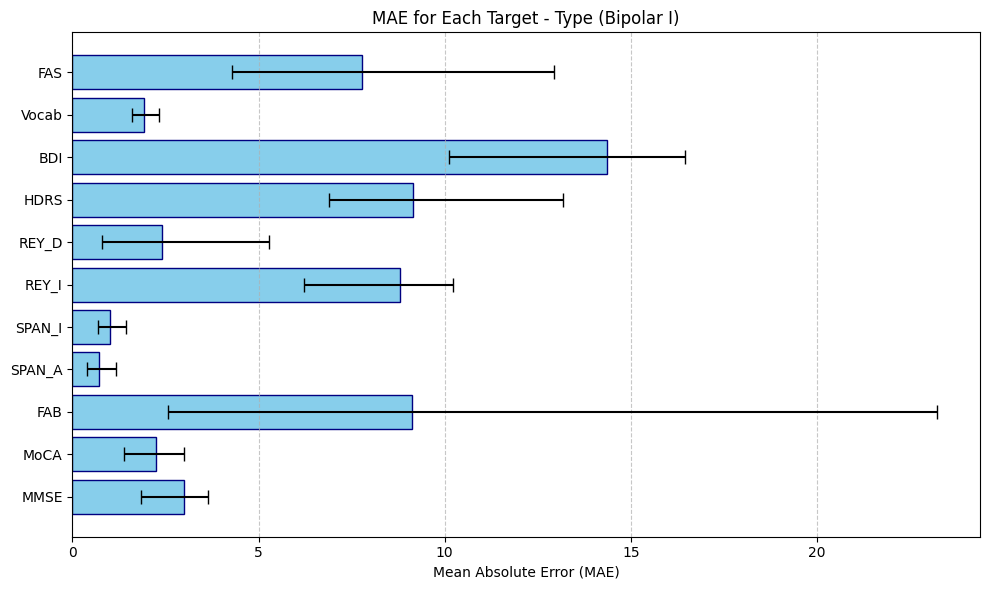

In [12]:
# Uncommented code, see previous models!!!

X_initial = t0_2
y_2 = pd.DataFrame(tdiff_2, columns=columns_2)
y_2.fillna(0, inplace=True)

features_to_keep = X_initial.columns[(X_initial > 1).any()]
X_2 = X_initial[features_to_keep].copy()

print(f"Original feature count: {X_initial.shape[1]}")
print(f"Filtered feature count (values > 1): {X_2.shape[1]}")

best_models_per_target = {}
coefficients_per_target = {}
mca_contributions_per_target = {}
mca_loadings_per_target = {}

mae_scores = []
mae_ci_lower = []
mae_ci_upper = []

mse_scores = []
mse_ci_low_list = []
mse_ci_high_list = []

target_names = []
if 'target_comparison_bp' not in locals():
    target_comparison_bp = {}

max_possible_comps = X_2.shape[1]
potential_comps = [5, 15, 30]
valid_comps = [c for c in potential_comps if c < max_possible_comps]
if not valid_comps:
    valid_comps = [max(1, max_possible_comps - 1)]

param_grid = {
    'mca__n_components': valid_comps,
    'model__alpha': [0.1, 1, 10]
}

outer_cv = KFold(n_splits=5, shuffle=True, random_state=44852523)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=73491241)

for idx, target in enumerate(y_2.columns):
    print(f"Processing Target {idx}: {target}")
    y_target = y_2[target]
    
    test_scores_mae = []
    test_scores_mse = []
    test_scores_r2 = []
    

    pipeline = Pipeline([
        ('mca', prince.MCA(
            n_iter=5000, copy=True, check_input=True, 
            engine='sklearn', random_state=283434922)),
        ('model', Ridge())
    ])

    for train_idx, test_idx in outer_cv.split(X_2, y_target):
        X_train_cv, X_test_cv = X_2.iloc[train_idx], X_2.iloc[test_idx]
        y_train_cv, y_test_cv = y_target.iloc[train_idx], y_target.iloc[test_idx]
        
        grid_search_cv = GridSearchCV(
            pipeline, param_grid, cv=inner_cv, 
            scoring='neg_mean_absolute_error', n_jobs=8
        )
        grid_search_cv.fit(X_train_cv, y_train_cv)
        
        y_pred = grid_search_cv.best_estimator_.predict(X_test_cv)
        
        test_scores_mae.append(mean_absolute_error(y_test_cv, y_pred))
        test_scores_mse.append(mean_squared_error(y_test_cv, y_pred))
        
        if len(np.unique(y_test_cv)) > 1 and np.std(y_pred) > 0:
            r2 = np.corrcoef(y_test_cv, y_pred)[0][1]**2
        else:
            r2 = 0.0
        test_scores_r2.append(r2)

    final_grid = GridSearchCV(pipeline, param_grid, cv=inner_cv, 
                              scoring='neg_mean_absolute_error', n_jobs=8)
    final_grid.fit(X_2, y_target)
    
    final_model = final_grid.best_estimator_
    best_models_per_target[target] = final_model
    
    ridge_step = final_model.named_steps['model']
    mca_step = final_model.named_steps['mca']
    
    coefficients_per_target[target] = ridge_step.coef_
    mca_contributions_per_target[target] = mca_step.column_contributions_
    mca_loadings_per_target[target] = mca_step.column_coordinates(X_2)

    curr_mean_mae = np.mean(test_scores_mae)
    curr_mean_mse = np.mean(test_scores_mse)
    curr_mean_r2 = np.mean(test_scores_r2)
    
    low_mae, high_mae = np.percentile(test_scores_mae, [2.5, 97.5])
    low_mse, high_mse = np.percentile(test_scores_mse, [2.5, 97.5])
    
    mae_scores.append(curr_mean_mae)
    mae_ci_lower.append(low_mae)
    mae_ci_upper.append(high_mae)
    
    mse_scores.append(curr_mean_mse)
    mse_ci_low_list.append(low_mse)
    mse_ci_high_list.append(high_mse)
    
    target_names.append(target)

    print(f"{target} Done | Mean R2: {curr_mean_r2:.4f} | Mean MAE: {curr_mean_mae:.4f} | Mean MSE: {curr_mean_mse:.4f}")

    strategy_name = "Type" 
    if target not in target_comparison_bp:
        target_comparison_bp[target] = {}
    
    target_comparison_bp[target][strategy_name] = {
        'mse': curr_mean_mse,
        'low': low_mse,
        'high': high_mse
    }

plt.figure(figsize=(10, 6))
error_bars = [
    np.array(mae_scores) - np.array(mae_ci_lower), 
    np.array(mae_ci_upper) - np.array(mae_scores)
]
plt.barh(target_names, mae_scores, xerr=error_bars, capsize=5, color='skyblue', edgecolor='navy')
plt.xlabel('Mean Absolute Error (MAE)')
plt.title('MAE for Each Target - Type (Bipolar I)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Original feature count: 40
Filtered feature count (max value of 1): 26
Processing Target 0: MMSE
MMSE Done | Mean Pearson R2: 0.1672 | Mean MAE: 4.0653 | Mean MSE: 24.6848
Processing Target 1: MoCA
MoCA Done | Mean Pearson R2: 0.5052 | Mean MAE: 2.6754 | Mean MSE: 11.4895
Processing Target 2: FAB
FAB Done | Mean Pearson R2: 0.3878 | Mean MAE: 8.8925 | Mean MSE: 485.2238
Processing Target 3: SPAN_A
SPAN_A Done | Mean Pearson R2: 0.3993 | Mean MAE: 0.8507 | Mean MSE: 1.1287
Processing Target 4: SPAN_I
SPAN_I Done | Mean Pearson R2: 0.0694 | Mean MAE: 1.0641 | Mean MSE: 1.9812
Processing Target 5: REY_I
REY_I Done | Mean Pearson R2: 0.4261 | Mean MAE: 7.9899 | Mean MSE: 96.6688
Processing Target 6: REY_D
REY_D Done | Mean Pearson R2: 0.2259 | Mean MAE: 2.4592 | Mean MSE: 13.1084
Processing Target 7: HDRS
HDRS Done | Mean Pearson R2: 0.2199 | Mean MAE: 8.8257 | Mean MSE: 123.4083
Processing Target 8: BDI
BDI Done | Mean Pearson R2: 0.7048 | Mean MAE: 14.0778 | Mean MSE: 322.4254
Processing

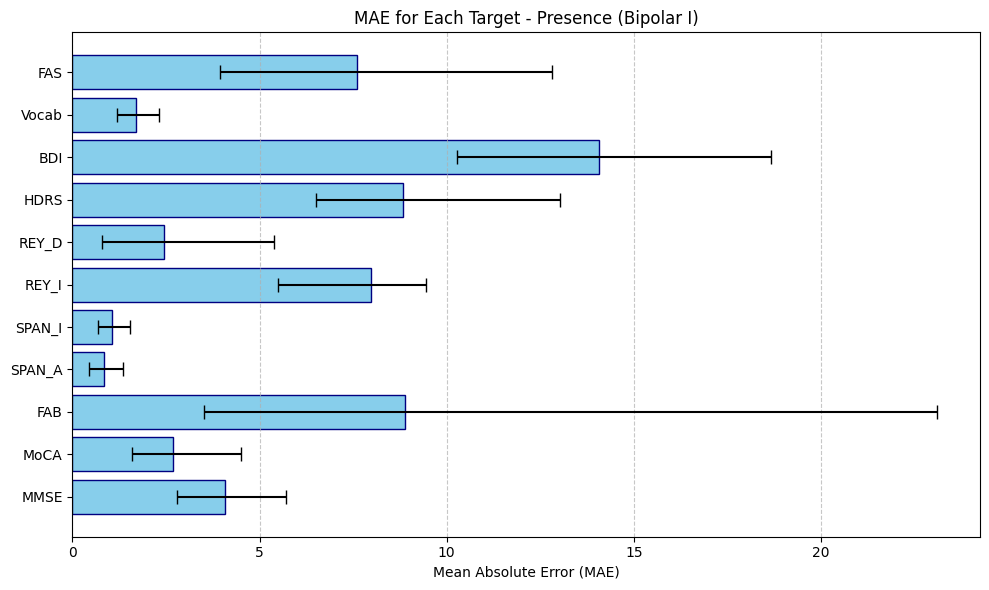

In [13]:
# Uncommented code, see previous models!!!

X_initial = t0_2
y_2 = pd.DataFrame(tdiff_2, columns=columns_2)
y_2.fillna(0, inplace=True)

features_to_keep = X_initial.columns[(X_initial.max() <= 1) & (X_initial.nunique() > 1)]
X_2 = X_initial[features_to_keep].copy()

print(f"Original feature count: {X_initial.shape[1]}")
print(f"Filtered feature count (max value of 1): {X_2.shape[1]}")

best_models_per_target = {}
coefficients_per_target = {}
mca_contributions_per_target = {}
mca_loadings_per_target = {}

mae_scores = []
mae_ci_lower = []
mae_ci_upper = []

mse_scores = []
mse_ci_low_list = []
mse_ci_high_list = []

target_names = []

max_possible_comps = X_2.shape[1]
potential_comps = [5, 15, 30]
valid_comps = [c for c in potential_comps if c < max_possible_comps]
if not valid_comps:
    valid_comps = [max(1, max_possible_comps - 1)]

param_grid = {
    'mca__n_components': valid_comps,
    'model__alpha': [0.1, 1, 10]
}

outer_cv = KFold(n_splits=5, shuffle=True, random_state=44852523)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=73491241)

for idx, target in enumerate(y_2.columns):
    print(f"Processing Target {idx}: {target}")
    y_target = y_2[target]
    
    test_scores_mae = []
    test_scores_mse = []
    test_scores_r2 = []
    
    pipeline = Pipeline([
        ('mca', prince.MCA(
            n_iter=5000, copy=True, check_input=True, 
            engine='sklearn', random_state=283434922)),
        ('model', Ridge())
    ])

    for train_idx, test_idx in outer_cv.split(X_2, y_target):
        X_train_cv, X_test_cv = X_2.iloc[train_idx], X_2.iloc[test_idx]
        y_train_cv, y_test_cv = y_target.iloc[train_idx], y_target.iloc[test_idx]
        
        grid_search_cv = GridSearchCV(
            pipeline, param_grid, cv=inner_cv, 
            scoring='neg_mean_absolute_error', n_jobs=8
        )
        grid_search_cv.fit(X_train_cv, y_train_cv)
        
        y_pred = grid_search_cv.best_estimator_.predict(X_test_cv)
        
        test_scores_mae.append(mean_absolute_error(y_test_cv, y_pred))
        test_scores_mse.append(mean_squared_error(y_test_cv, y_pred)) # Added MSE
        
        if len(np.unique(y_test_cv)) > 1 and np.std(y_pred) > 0:
            r2 = np.corrcoef(y_test_cv, y_pred)[0][1]**2
        else:
            r2 = 0.0
        test_scores_r2.append(r2)

    final_grid = GridSearchCV(pipeline, param_grid, cv=inner_cv, 
                              scoring='neg_mean_absolute_error', n_jobs=8)
    final_grid.fit(X_2, y_target)
    
    final_model = final_grid.best_estimator_
    best_models_per_target[target] = final_model
    
    ridge_step = final_model.named_steps['model']
    mca_step = final_model.named_steps['mca']
    
    coefficients_per_target[target] = ridge_step.coef_
    mca_contributions_per_target[target] = mca_step.column_contributions_
    mca_loadings_per_target[target] = mca_step.column_coordinates(X_2)

    m_mae = np.mean(test_scores_mae)
    m_mse = np.mean(test_scores_mse)
    m_r2 = np.mean(test_scores_r2)
    
    low_mae, high_mae = np.percentile(test_scores_mae, [2.5, 97.5])
    low_mse, high_mse = np.percentile(test_scores_mse, [2.5, 97.5])
    
    target_names.append(target)
    mae_scores.append(m_mae)
    mae_ci_lower.append(low_mae)
    mae_ci_upper.append(high_mae)
    
    mse_scores.append(m_mse)
    mse_ci_low_list.append(low_mse)
    mse_ci_high_list.append(high_mse)

    print(f"{target} Done | Mean Pearson R2: {m_r2:.4f} | Mean MAE: {m_mae:.4f} | Mean MSE: {m_mse:.4f}")

    strategy_name = "Presence" 
    if target not in target_comparison_bp:
        target_comparison_bp[target] = {}
        
    target_comparison_bp[target][strategy_name] = {
        'mse': m_mse,
        'low': low_mse,
        'high': high_mse
    }

plt.figure(figsize=(10, 6))
error_bars = [
    np.array(mae_scores) - np.array(mae_ci_lower), 
    np.array(mae_ci_upper) - np.array(mae_scores)
]
plt.barh(target_names, mae_scores, xerr=error_bars, capsize=5, color='skyblue', edgecolor='navy')
plt.xlabel('Mean Absolute Error (MAE)')
plt.title('MAE for Each Target - Presence (Bipolar I)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Comparison between Full, Type and Presence predictive models

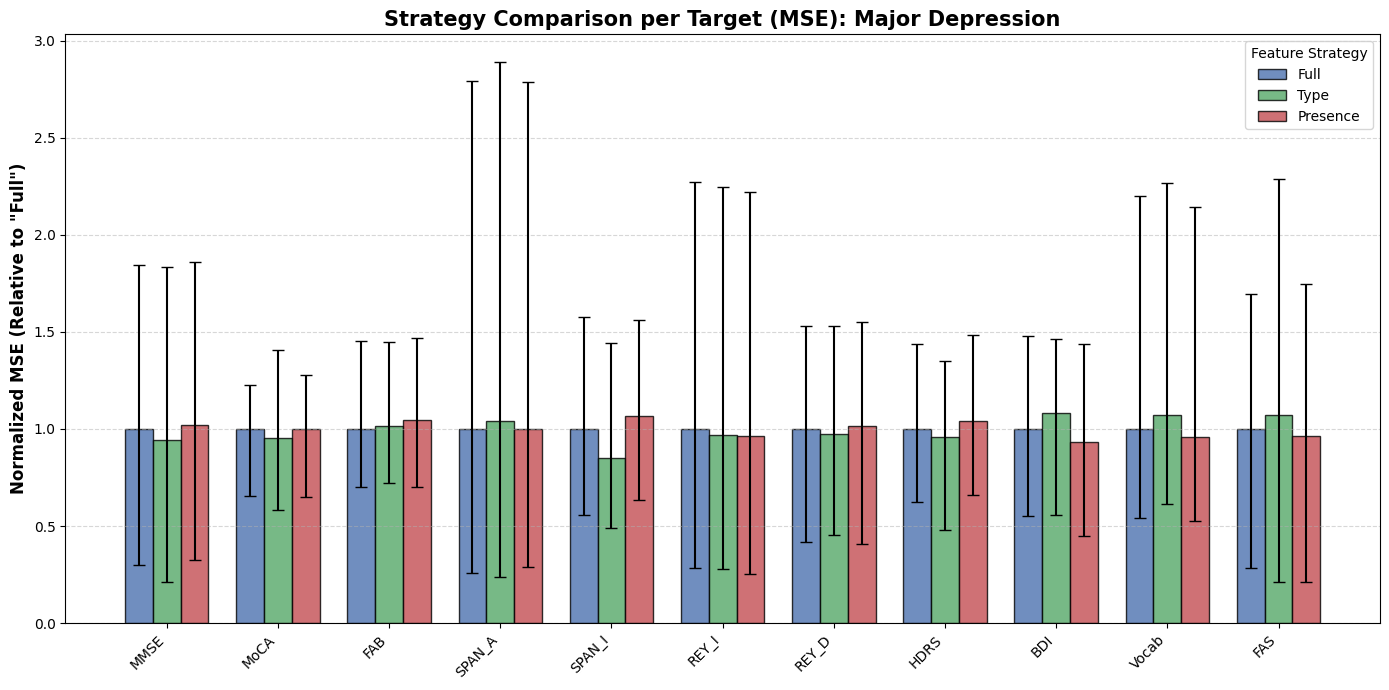

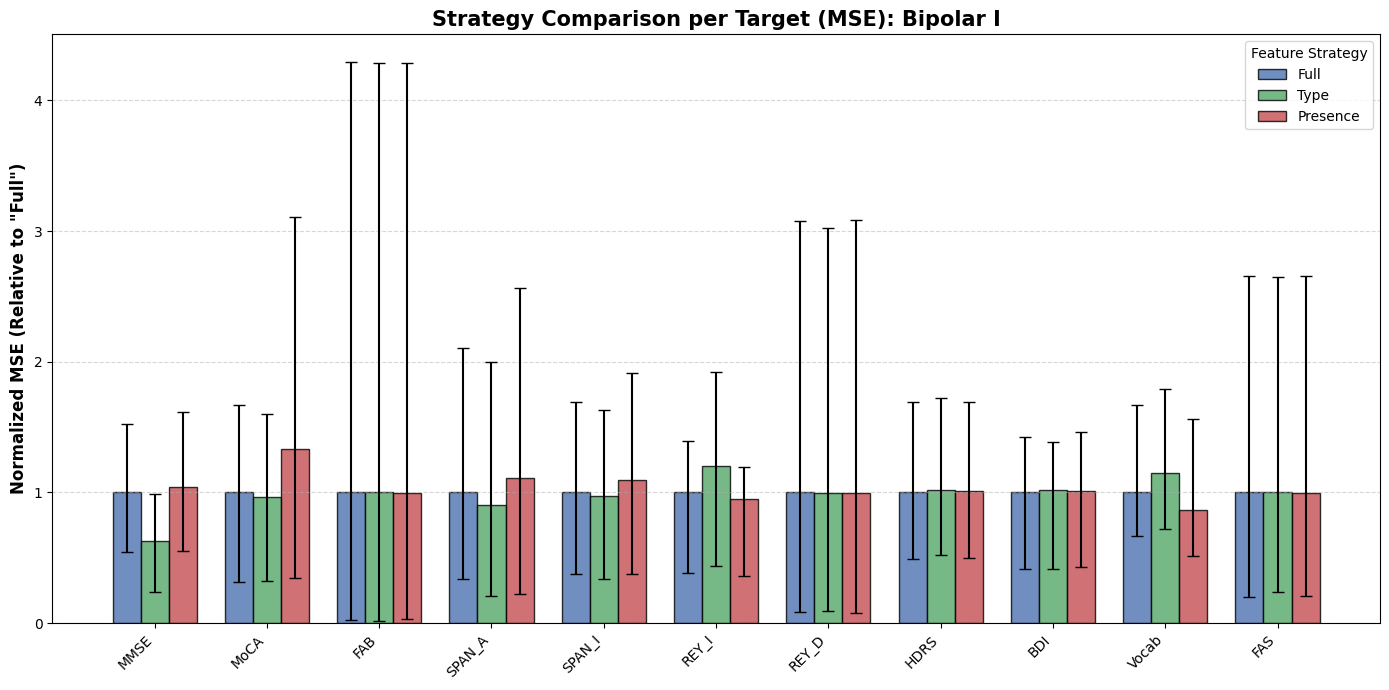

In [14]:
def plot_grouped_comparison_mse(data_dict, title, significance_dict=None):
    targets = list(data_dict.keys())
    strategies = ["Full", "Type", "Presence"]
    colors = ['#4C72B0', '#55A868', '#C44E52']

    x = np.arange(len(targets))
    width = 0.25

    fig, ax = plt.subplots(figsize=(14, 7))

    # Store normalized data for plotting later
    all_means = {s: [] for s in strategies}
    all_errs_low = {s: [] for s in strategies}
    all_errs_high = {s: [] for s in strategies}

    for t in targets:
        # Define the normalization factor (using 'Full' strategy as baseline)
        baseline_val = data_dict[t].get('Full', {}).get('mse', 1.0)
        norm_factor = baseline_val if baseline_val != 0 else 1.0

        for strategy in strategies:
            res = data_dict[t].get(strategy, {'mse': 0, 'low': 0, 'high': 0})

            # 2. Normalize values
            m_norm = res['mse'] / norm_factor
            low_norm = res['low'] / norm_factor
            high_norm = res['high'] / norm_factor

            all_means[strategy].append(m_norm)

            # Calculate error bar lengths relative to the normalized mean
            all_errs_low[strategy].append(max(0, m_norm - low_norm))
            all_errs_high[strategy].append(max(0, high_norm - m_norm))

    for i, strategy in enumerate(strategies):
        offset = (i - 1) * width
        ax.bar(x + offset, all_means[strategy], width,
               yerr=[all_errs_low[strategy], all_errs_high[strategy]],
               label=strategy, color=colors[i], capsize=4, edgecolor='black', alpha=0.8)

    ax.set_ylabel('Normalized MSE (Relative to "Full")', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=15, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(targets, rotation=45, ha='right')
    ax.legend(title="Feature Strategy")
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # 4. Add statistical significance markers
    if significance_dict:
        y_max = max([max(all_means[s]) for s in strategies]) * 1.1
        for i, target in enumerate(targets):
            for j, pair in enumerate([("Full", "Type"), ("Full", "Presence"), ("Type", "Presence")]):
                s1, s2 = pair
                p = significance_dict[target].get(pair, 1.0)
                if p < 0.05:
                    y = y_max + 0.05 * (j + 1)
                    ax.plot([x[i] - width, x[i] + width], [y, y], color='black', lw=1)
                    ax.text((x[i] - width + x[i] + width) / 2, y, '*', ha='center', va='bottom', color='black')

    plt.tight_layout()
    plt.show()

# Show plots
plot_grouped_comparison_mse(target_comparison_md, "Strategy Comparison per Target (MSE): Major Depression")
plot_grouped_comparison_mse(target_comparison_bp, "Strategy Comparison per Target (MSE): Bipolar I")